In [2]:
import os
import sys

sys.path.append("../")

envkey = "OMP_NUM_THREADS"
# Set this environment variable to the number of available cores in your machine,
# to get a fast execution of the Einstein Boltzmann Solver
print("The value of {:s} is: ".format(envkey), os.environ.get(envkey))
os.environ[envkey] = str(12)
os.environ[envkey] = str(12)
print("The value of {:s} is: ".format(envkey), os.environ.get(envkey))

The value of OMP_NUM_THREADS is:  None
The value of OMP_NUM_THREADS is:  12


In [3]:
import astropy.units as u
import matplotlib as mpl
import matplotlib.pyplot as plt
import niceplots.utils as nicepl
import numpy as np
import seaborn
import seaborn as sns
from astropy.constants import c as cel
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from scipy.special import roots_legendre, spherical_jn

nicepl.initPlot()
Cs = seaborn.color_palette("colorblind")
Cp = seaborn.color_palette("Paired")
Cs

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [4]:
Cp

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

In [5]:
# Import Main modules. This might take some time as some functions compile before time
from SSLimPy.interface import sslimpy
from SSLimPy.LIMsurvey import covariance as scov
from SSLimPy.LIMsurvey import power_spectrum as spobs

In [6]:
def corr(cov):
    dcov = np.diag(cov)
    corr = cov / np.sqrt(np.outer(dcov, dcov))
    return corr

In [7]:
settings = {
    "code":"class", # The Einstein--Boltzman solver that should be used
    "do_RSD" : False, # If RSD should be considerd
    "nonlinearRSD" : False, # If you want to add FOG to the RSD
    "QNLpowerspectrum": False, # Use dewiggled power spectrum (vlasov approximation of nonlinear structure formation)
    "FoG_damp" : "ISTF_like", # The particular parametrization for the FOG. Check PowerSpectrum for the full list
    "halo_model_PS" : True, # If the cosmological shotnoise should be computed from the halo model 
    "output" : ["Power spectrum", "Covariance"], # What output one wants (here power spectrum and Gaussian covariance only)
    "kmin": 1e-4 * u.Mpc**-1,
    "kmax": 50 * u.Mpc**-1,
    "nk": 200,
    "Smooth_resolution": True,
    # "nonlinearMatpow": False,
}

h = 0.677
cosmodict={
    "h": h,
    "Omegam": 0.309167,
    "Omegab": 0.04903,
    "sigma8":0.8222,
    "ns":0.96824,
    "mnu":0.06,
    "Neff":3.044,
}

# Parameters that enter your halo model. Typically they are not changed but you could
halodict={
    "halo_tracer" : "clustering", # Computes all halo quantities from the matter field - neutrinos
    "hmf_model": "ST", # Sheth--Tormann halo mass function
    "concentration": "Diemer19", # Diemer19 halo concentration relation
    "bias_model": "ST99",
    "nonlinear_bias": "HMF",
}

In [8]:
myssl = sslimpy.SSLimPy(
    settings_dict=settings,
    cosmopars=cosmodict,
    halopars=halodict,
)

  █████   █████  █       █            █████   █    █ 
 █     █ █     █ █            █   █   █    █  █   █  
 █       █       █     ███   █ █ █ █  █    █   █ █   
  █████   █████  █       █   █  █  █  █████     █    
       █       █ █       █   █     █  █        █     
 █     █ █     █ █       █   █     █  █       █      
  █████   █████  █████ █████ █     █  █      █       

#---------------------------------------------------#


In [9]:
mycosmo = myssl.current_cosmology

In [10]:
nu = 997.4 * u.MHz
lamda = (cel / nu).to(u.m)
beam = ((lamda / (12.5*u.m)).to(1).value * u.rad).to(u.deg)

surveyspecs_MK = {
    "Tsys_NEFD": 21 * u.K,
    "Nfeeds": 2,
    "nD": 64,
    "beam_FWHM": beam,
    "nu": 1420 * u.MHz,
    "nuObs": nu,
    "Delta_nu": 52.4 * u.MHz,
    "dnu": 0.209 * u.MHz,
    "tobs": 43 * u.h,
    "Omega_field": 236 * u.deg**2
}

astrodict_HI={
    "model_type": "ML",
    "model_name": "MHI_21cm_Obuljen",
    "model_par": {
        "alpha": 0.44,
        "M0": 10**9.52 * myssl.current_astro.Msunh,
        "Mmin":10**11.27 * myssl.current_astro.Msunh,
        "do_quench": False,
    },
    "sigma_scatter" : 0.2,
}

pobs_L = myssl.compute(
    myssl.current_cosmology.cosmopars,
    myssl.current_halomodel.haloparams,
    astrodict_HI,
    surveyspecs_MK,
    pobs_settings={
        "kmin":2e-2 * u.Mpc**-1,
        "kmax":0.5 * u.Mpc**-1,
        "nk":30,
    },
    output=["Power spectrum"]
)["Power spectrum"]
myastro_L = pobs_L.astro

In [11]:
gcov = scov.Covariance(pobs_L)
G_SS_cov_L = np.diag(gcov.gaussian_nonoise_cov()[:, 0, 0, 0])
G_SN_cov_L = np.diag(gcov.gaussian_signalxnoise_cov()[:, 0, 0, 0])
G_NN_cov_L = np.diag(gcov.gaussian_noise_cov()[:, 0, 0, 0])
G_cov_L = G_SS_cov_L + G_SN_cov_L + G_NN_cov_L

NG_cov_L = scov.nonGuassianCov(pobs_L).compute_nG_Cov().squeeze()
SSC_cov_L = scov.SuperSampleCovariance(pobs_L).compute_SSC().squeeze()

cov_L = G_cov_L + NG_cov_L + SSC_cov_L
corr_L = corr(cov_L)

/home/sefa/Desktop/projects/LIM-Code/SSLimPy/notebooks/../SSLimPy/LIMsurvey/ingredients_T0.py:679: RuntimeWarning: invalid value encountered in power
  * np.power(np.abs(k1 - k2), an)
/home/sefa/Desktop/projects/LIM-Code/SSLimPy/notebooks/../SSLimPy/LIMsurvey/covariance.py:442: RuntimeWarning: divide by zero encountered in divide
  k = ((1 / t - 1) ** alpha) / scale
/home/sefa/Desktop/projects/LIM-Code/SSLimPy/notebooks/../SSLimPy/LIMsurvey/covariance.py:447: RuntimeWarning: divide by zero encountered in divide
  jacobian = alpha / (t * (1.0 - t))
/home/sefa/Desktop/projects/LIM-Code/SSC-project/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/sefa/Desktop/projects/LIM-Code/SSC-project/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in multiply
  result = super().__array_ufunc__(function, meth

In [12]:
nu = 745 * u.MHz
lamda = (cel / nu).to(u.m)
beam = ((lamda / (12.5*u.m)).to(1).value * u.rad).to(u.deg)

surveyspecs_MK = {
    "Tsys_NEFD": 25 * u.K,
    "Nfeeds": 2,
    "nD": 64,
    "beam_FWHM": beam,
    "nu": 1420 * u.MHz,
    "nuObs": nu,
    "Delta_nu": 185 * u.MHz,
    "dnu": 0.209 * u.MHz,
    "tobs": 57 * u.h,
    "Omega_field": 256 * u.deg**2
}

astrodict_HI={
    "model_type": "ML",
    "model_name": "MHI_21cm_Obuljen",
    "model_par": {
        "alpha": 0.44,
        "M0": 10**9.52 * myssl.current_astro.Msunh,
        "Mmin":10**11.27 * myssl.current_astro.Msunh,
        "do_quench": False,
    },
    "sigma_scatter" : 0.25,
}

pobs_UHF = myssl.compute(
    myssl.current_cosmology.cosmopars,
    myssl.current_halomodel.haloparams,
    astrodict_HI,
    surveyspecs_MK,
    pobs_settings={
        "kmin":1e-2 * u.Mpc**-1,
        "kmax":0.25 * u.Mpc**-1,
        "nk":30,
    },
    output=["Power spectrum"]
)["Power spectrum"]
astro_UHF = pobs_UHF

In [13]:
pobs_UHF.survey_specs.get_redshifts()

(np.float64(0.6955223880597015),
 np.float64(0.9060402684563758),
 np.float64(1.1762452107279695))

In [14]:
(pobs_UHF.survey_specs.sigma_Noise()**2).to(u.uK**2)

<Quantity 3626.18489515 uK2>

In [15]:
gcov = scov.Covariance(pobs_UHF)
G_SS_cov_UHF = np.diag(gcov.gaussian_nonoise_cov()[:, 0, 0, 0])
G_SN_cov_UHF = np.diag(gcov.gaussian_signalxnoise_cov()[:, 0, 0, 0])
G_NN_cov_UHF = np.diag(gcov.gaussian_noise_cov()[:, 0, 0, 0])
G_cov_UHF = G_SS_cov_UHF + G_SN_cov_UHF + G_NN_cov_UHF

NG_cov_UHF = scov.nonGuassianCov(pobs_UHF).compute_nG_Cov().squeeze()
SSC_cov_UHF = scov.SuperSampleCovariance(pobs_UHF).compute_SSC().squeeze()

cov_UHF = G_cov_UHF + NG_cov_UHF + SSC_cov_UHF
corr_UHF = corr(cov_UHF)

In [16]:
nu = 280 * u.GHz
FWHMnu = nu / 100
dnu = FWHMnu / np.sqrt(8 * np.log(2))

surveyspecs_CCATp = {
    "Tsys_NEFD": 81/10 * u.mJy * u.s**0.5, #/ np.sqrt(6912)
    "Nfeeds": 6912,
    "nD": 1,
    "beam_FWHM": 48 * u.arcsec,
    "nu": 1.901 * u.THz,
    "nuObs": nu,
    "Delta_nu": 40 * u.GHz,
    "dnu": dnu,
    "tobs": 2000 / 42 * u.h,
    "Omega_field": 4 * u.deg**2,
    "do_Jysr": True,
}

astrodict_CCATp={
    "model_type": "ML",
    "model_name": "SilvaCII",
    "model_par": {
        "a": 0.8475,
        "b": 7.2203,
        "SFR_file": "sfr_release.dat",
        "do_quench": False,
    },
    "sigma_scatter" : 0.37,
}

pobs_CII = myssl.compute(
    myssl.current_cosmology.cosmopars,
    myssl.current_halomodel.haloparams,
    astrodict_CCATp,
    surveyspecs_CCATp,
    pobs_settings={
        "kmin":3e-2 * u.Mpc**-1,
        "kmax":2 * u.Mpc**-1,
        "nk":50,
    },
    output=["Power spectrum"]
)["Power spectrum"]
myastro_CII = pobs_CII.astro

/home/sefa/Desktop/projects/LIM-Code/SSC-project/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/sefa/Desktop/projects/LIM-Code/SSLimPy/notebooks/../SSLimPy/cosmology/astro.py:166: RuntimeWarning: divide by zero encountered in log
  np.log(L_of_M.value)[:, None, :] - 0.5 * sigma_base_e**2.0,


In [17]:
G_SS_cov_CII = np.diag(scov.Covariance(pobs_CII).gaussian_nonoise_cov()[:, 0, 0, 0])
G_SN_cov_CII = np.diag(scov.Covariance(pobs_CII).gaussian_signalxnoise_cov()[:, 0, 0, 0])
G_NN_cov_CII = np.diag(scov.Covariance(pobs_CII).gaussian_noise_cov()[:, 0, 0, 0])
G_cov_CII = G_SS_cov_CII + G_SN_cov_CII + G_NN_cov_CII

NG_cov_CII = scov.nonGuassianCov(pobs_CII).compute_nG_Cov().squeeze()
SSC_cov_CII = scov.SuperSampleCovariance(pobs_CII).compute_SSC().squeeze()
cov_CII = G_cov_CII + NG_cov_CII + SSC_cov_CII
corr_CII = corr(cov_CII)

In [18]:
labels = [
    r"$\mathrm{Cov}^{\rm TT}_{\rm G}$",
    r"$\mathrm{Cov}^{\rm TN}_{\rm G}$",
    r"$\mathrm{Cov}^{\rm NN}_{\rm G}$",
    r"$\mathrm{Cov}_{\rm NG}$",
    r"$\mathrm{Cov}_{\rm SSC}$"
]

In [20]:
Cs

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [ ]:
print(Cs)


[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00784313725490196, 0.6196078431372549, 0.45098039215686275), (0.8352941176470589, 0.3686274509803922, 0.0), (0.8, 0.47058823529411764, 0.7372549019607844), (0.792156862745098, 0.5686274509803921, 0.3803921568627451), (0.984313725490196, 0.6862745098039216, 0.8941176470588236), (0.5803921568627451, 0.5803921568627451, 0.5803921568627451), (0.9254901960784314, 0.8823529411764706, 0.2), (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]


In [29]:
(239, 68, 68)

(239, 68, 68)

In [33]:
Cs = [Cs[0], Cs[8], Cs[2], Cs[3], Cs[4], Cs[5]]

/home/sefa/Desktop/projects/LIM-Code/SSC-project/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/sefa/Desktop/projects/LIM-Code/SSC-project/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


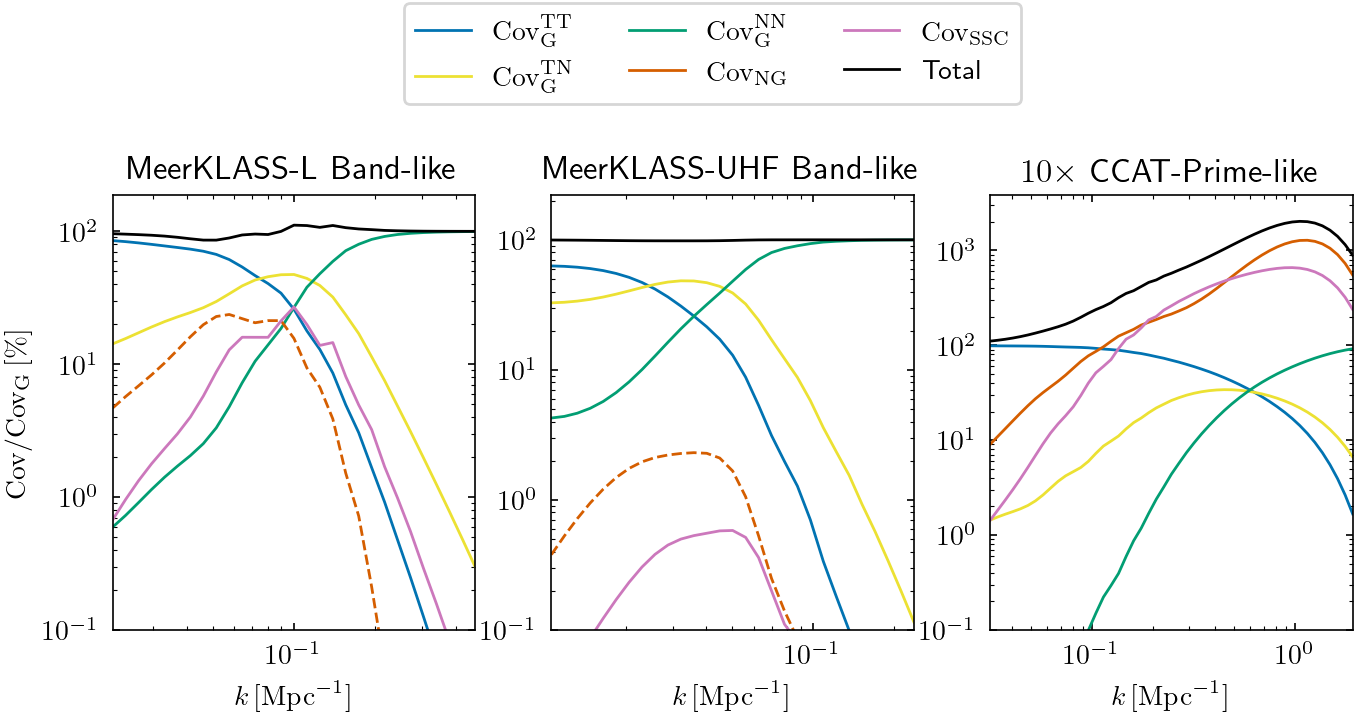

In [34]:
fw, fh = plt.rcParams["figure.figsize"]
fig, axs = plt.subplots(
    1, 3,
    figsize=(2 * fw, fh),
)

covs_L = [G_SS_cov_L, G_SN_cov_L, G_NN_cov_L, NG_cov_L, SSC_cov_L]
covs_L = np.array([cov.to(G_SS_cov_L.unit).value for cov in covs_L]) * G_SS_cov_L.unit
k, Pk = pobs_L.k, pobs_L.Pk_0bs.squeeze()
color = iter(Cs)
for cov, label in zip(covs_L, labels):
    c = next(color)
    axs[0].loglog(k,  np.diag(cov / G_cov_L) * 100, c=c, label=label)
    axs[0].loglog(k, -np.diag(cov / G_cov_L) * 100, c=c, ls="--")
axs[0].loglog(k, np.diag(cov_L / G_cov_L) * 100, c="k", label="Total")


covs_UHF = [G_SS_cov_UHF, G_SN_cov_UHF, G_NN_cov_UHF, NG_cov_UHF, SSC_cov_UHF]
covs_UHF = np.array([cov.to(G_SS_cov_UHF.unit).value for cov in covs_UHF]) * G_SS_cov_UHF.unit
k, Pk = pobs_UHF.k, pobs_UHF.Pk_0bs.squeeze()
color = iter(Cs)
for cov, label in zip(covs_UHF, labels):
    c = next(color)
    axs[1].loglog(k,  np.diag(cov / G_cov_UHF) * 100, c=c, label=label)
    axs[1].loglog(k, -np.diag(cov / G_cov_UHF) * 100, c=c, ls="--")
axs[1].loglog(k, np.diag(cov_UHF / G_cov_UHF) * 100, c="k", label="Total")


covs_CII = [G_SS_cov_CII, G_SN_cov_CII, G_NN_cov_CII, NG_cov_CII, SSC_cov_CII]
covs_CII = np.array([cov.to(G_SS_cov_CII.unit).value for cov in covs_CII]) * G_SS_cov_CII.unit
k, Pk = pobs_CII.k, pobs_CII.Pk_0bs.squeeze()
color = iter(Cs)
for cov, label in zip(covs_CII, labels):
    c = next(color)
    axs[2].loglog(k,  np.diag(cov / G_cov_CII) * 100, c=c, label=label)
    axs[2].loglog(k, -np.diag(cov / G_cov_CII) * 100, c=c, ls="--")
axs[2].loglog(k, np.diag(cov_CII / G_cov_CII) * 100, c="k", label="Total")

axs[0].set_ylabel(r"$\mathrm{Cov} / \mathrm{Cov}_\mathrm{G}\,[\%]$")
[ax.set_xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$") for ax in axs]
[ax.set_ylim(1e-1,None) for ax in axs]
# [ax.set_yscale("linear") for ax in axs]
[ax.set_box_aspect(1.2) for ax in axs]

axs[0].set_title(" MeerKLASS-L Band-like")
axs[1].set_title(" MeerKLASS-UHF Band-like")
axs[2].set_title(r"$10\times$ CCAT-Prime-like")

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center",
           bbox_to_anchor=(0.5, 1.2),
           ncol=3)
fig.subplots_adjust(wspace=0.21)

fig.savefig("output/new_covariance_diagonal_comparision.png")

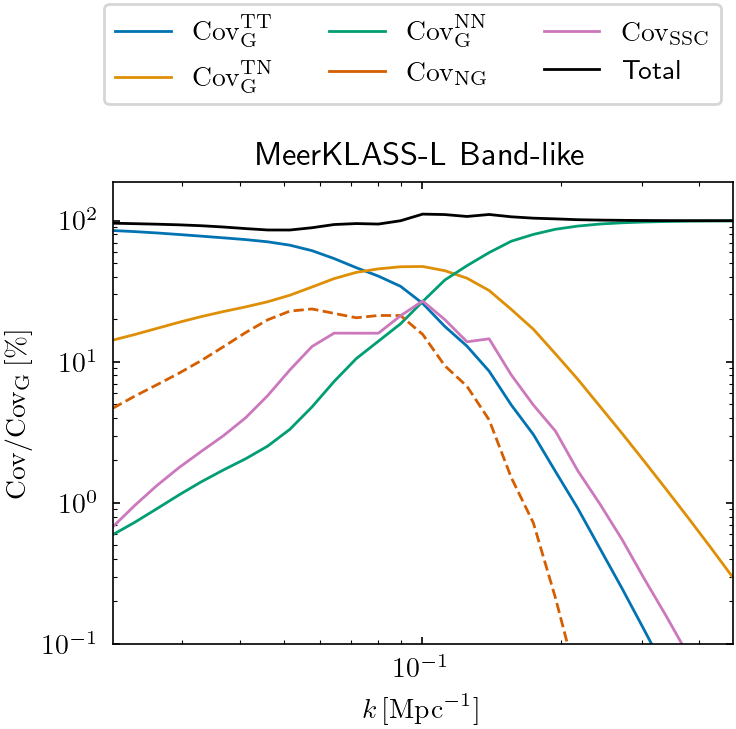

In [24]:
fig, ax = plt.subplots()

covs_L = [G_SS_cov_L, G_SN_cov_L, G_NN_cov_L, NG_cov_L, SSC_cov_L]
covs_L = np.array([cov.to(G_SS_cov_L.unit).value for cov in covs_L]) * G_SS_cov_L.unit
k, Pk = pobs_L.k, pobs_L.Pk_0bs.squeeze()
color = iter(Cs)
for cov, label in zip(covs_L, labels):
    c = next(color)
    ax.loglog(k,  np.diag(cov / G_cov_L) * 100, c=c, label=label)
    ax.loglog(k, -np.diag(cov / G_cov_L) * 100, c=c, ls="--")
ax.loglog(k, np.diag(cov_L / G_cov_L) * 100, c="k", label="Total")


ax.set_ylabel(r"$\mathrm{Cov} / \mathrm{Cov}_\mathrm{G}\,[\%]$")
ax.set_ylim(1e-1,None)
ax.set_xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$")
ax.set_title(" MeerKLASS-L Band-like")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center",
           bbox_to_anchor=(0.5, 1.2),
           ncol=3)

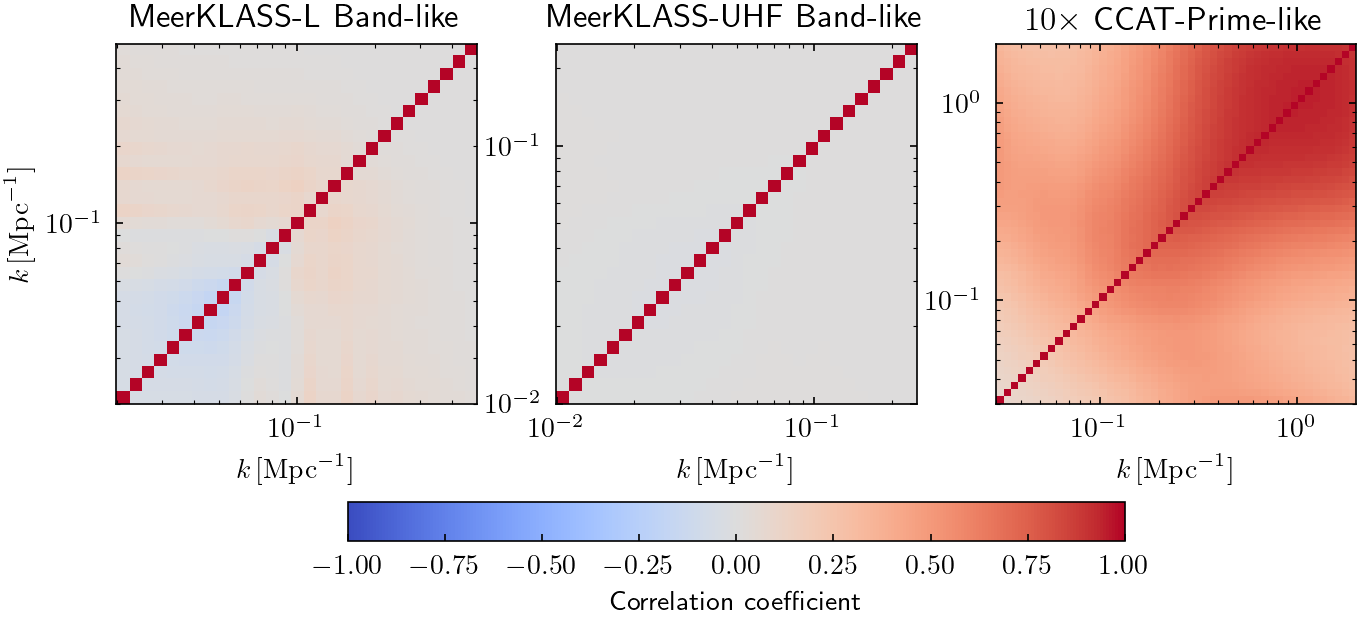

In [ ]:
fw, fh = plt.rcParams["figure.figsize"]
fig, axs = plt.subplots(
    1, 3,
    figsize=(2 * fw, 1.2 * fh),
)

axs[0].set_ylabel(r"$k\,[\mathrm{Mpc}^{-1}]$")
[ax.set_xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$") for ax in axs]

mappable = None
for ax, pobs, C in zip(
    axs,
    [pobs_L, pobs_UHF, pobs_CII],
    [corr_L, corr_UHF, corr_CII],
):
    k = pobs.k
    mappable = ax.pcolormesh(
        k.value,
        k.value,
        C.value,
        vmin=-1,
        vmax=1,
        cmap="coolwarm",
    )
    ax.loglog()
    ax.set_aspect(1)

# Shared colorbar
cbar = fig.colorbar(
    mappable,
    ax=axs,
    fraction=0.07,
    orientation="horizontal"
)
cbar.set_label(r"Correlation coefficient")

fig.subplots_adjust(wspace=0.22, bottom=0.3)

axs[0].set_title(" MeerKLASS-L Band-like")
axs[1].set_title(" MeerKLASS-UHF Band-like")
axs[2].set_title(r"$10\times$ CCAT-Prime-like")

fig.savefig("output/corr_comparision.png")

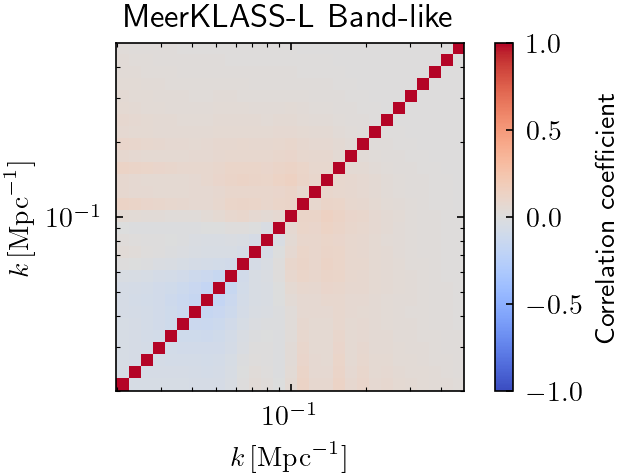

In [27]:
fw, fh = plt.rcParams["figure.figsize"]
fig, ax = plt.subplots()

ax.set_ylabel(r"$k\,[\mathrm{Mpc}^{-1}]$")
ax.set_xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$")

mappable = None

pobs = pobs_L
C = corr_L
k = pobs.k
mappable = ax.pcolormesh(
    k.value,
    k.value,
    C.value,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)
ax.loglog()
ax.set_aspect(1)

# Shared colorbar
cbar = fig.colorbar(
    mappable,
    ax=ax,
    fraction=0.07,
    orientation="vertical"
)
cbar.set_label(r"Correlation coefficient")

fig.subplots_adjust(wspace=0.22, bottom=0.3)

ax.set_title(" MeerKLASS-L Band-like")

fig.savefig("output/corr_comparision.png")

In [82]:
(pobs_UHF.survey_specs.sigma_Noise()**2).to(u.uK**2)

<Quantity 3626.18489515 uK2>

In [83]:
(pobs_L.survey_specs.sigma_Noise()**2).to(u.uK**2)


<Quantity 5607.57819732 uK2>

In [79]:
pobs_L.z, pobs_UHF.z, pobs_CII.z

(array([0.42370162]), array([0.90604027]), array([5.78928571]))

In [84]:
pobs_L.astro.Tavg(pobs_L.z)

<Quantity [77.62980364] uK>